# Fase 5 — sociodemografía y población

Se comparan dos representaciones: rasgos fijos del censo 2017 y estimaciones **anuales por distrito**, repetidas en las semanas de cada año. El eje urbano (CP1) se ajusta con la referencia 2017 de los distritos de entrenamiento de cada fold; esa misma escala transforma todos los años.

**La alternativa anual es una reconstrucción retrospectiva con los datos disponibles hoy.** Las 15 fracciones de 2018–2024 se interpolaron usando el extremo de 2025; por eso sus métricas no son un backtest estrictamente en tiempo real. La población 2018–2025 procede de proyecciones. La fecha de publicación de las versiones del Excel no consta.

La fecha de disponibilidad utilizada para **los orígenes de prueba** de la referencia censal es 2019-01-01, una barrera conservadora. Las etiquetas de 2017–2018 pueden servir para entrenar un modelo ajustado después. Se comparan conteos porque el umbral de alerta aún no está fijado. Ridge sigue siendo un diagnóstico, no el XGBoost final.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from src.eda.carga import cargar_integrado
from src.modeling.diagnostico_socio import contrastar_sociodemografia
from src.modeling.sociodemografia import referencia_2017
from src.utils.paths import BRONZE_SOCIO, DOCS, SILVER_INTEGRADO
from src.validation.expectations_integrado import coverage_path, load_case_coverage, validate_complete
SALIDA = DOCS / 'feature_engineering'
METRICAS = SALIDA / 'metricas'
FIGURAS = SALIDA / 'figuras' / 'fase5_sociodemografia'
METRICAS.mkdir(parents=True, exist_ok=True)
FIGURAS.mkdir(parents=True, exist_ok=True)

## 1. Linaje del corte censal

Se compara cada valor fijo del panel con la columna `_2017` o `pob_censada_2017` del Excel bronze; una discrepancia detiene la ejecución.

In [2]:
panel = cargar_integrado()
validate_complete(panel, load_case_coverage(coverage_path(SILVER_INTEGRADO)))
referencia = referencia_2017(panel).set_index('ubigeo')
bronce = pd.read_excel(BRONZE_SOCIO / 'data_socio_2017_2025.xlsx')
bronce['ubigeo'] = bronce.ubigeo.astype(str).str.zfill(6)
bronce = bronce.set_index('ubigeo')
desvios = {}
for columna in referencia.columns:
    fuente = 'pob_censada_2017' if columna == 'poblacion' else f'{columna}_2017'
    desvios[columna] = float(np.abs(referencia[columna].astype(float) - bronce.loc[referencia.index, fuente].astype(float)).max())
assert len(referencia) == 65 and max(desvios.values()) == 0
print({'filas_panel': len(panel), 'distritos_referencia': len(referencia), 'desvio_maximo_bronze': max(desvios.values())})

{'filas_panel': 30485, 'distritos_referencia': 65, 'desvio_maximo_bronze': 0.0}


## 2. Aporte fuera de muestra

En temporadas 2022–2025 se compara historia y calendario contra población fija, tres fracciones fijas, CP1 fijo y sus versiones anuales. Además se prueba el bloque de las 15 fracciones anuales y población + CP1 anual sobre la base climática. Todas las variantes comparten las mismas filas y cortes. Se conservan los casos de 2017–2018 como ejemplos de entrenamiento; las etiquetas deben estar observadas antes del primer origen de cada fold. Las cifras de las variantes anuales solo describen la reconstrucción retrospectiva.

base  delta_poblacion_2017  delta_tres_fracciones_2017  \
horizonte temporada                                                             
2         2022        1.981                -0.006                      -0.000   
          2023       11.509                 0.039                       0.035   
          2024        4.896                -0.017                      -0.002   
          2025        0.459                -0.000                       0.000   
4         2022        2.535                -0.014                      -0.003   
          2023       15.421                 0.002                       0.019   
          2024        6.776                -0.054                      -0.027   
          2025        0.534                -0.001                       0.001   

                     delta_eje_2017  delta_poblacion_y_eje_2017  \
horizonte temporada                                               
2         2022               -0.001                      -0.006   
          2023                0.017                       0.047   
          2024               -0.017                      -0.028   
          2025               -0.000                      -0.001   
4         2022               -0.003                      -0.015   
          2023                0.003                       0.007   
          2024               -0.037                      -0.075   
          2025                0.000                       0.000   

                     delta_poblacion_anual  delta_tres_fracciones_anuales  \
horizonte temporada                                                         
2         2022                      -0.006                         -0.001   
          2023                       0.028                          0.022   
          2024                      -0.019                          0.001   
          2025                      -0.000                          0.005   
4         2022                      -0.014                         -0.002   
          2023                      -0.008                          0.003   
          2024                      -0.056                         -0.020   
          2025                       0.000                          0.012   

                     delta_eje_anual  delta_15_fracciones_anuales  \
horizonte temporada                                                 
2         2022                -0.001                        0.002   
          2023                 0.018                        0.071   
          2024                -0.012                       -0.018   
          2025                 0.002                        0.021   
4         2022                -0.002                       -0.011   
          2023                 0.004                        0.025   
          2024                -0.030                        0.028   
          2025                 0.005                        0.057   

                     delta_poblacion_y_eje_anual  \
horizonte temporada                                
2         2022                            -0.006   
          2023                             0.038   
          2024                            -0.027   
          2025                             0.001   
4         2022                            -0.014   
          2023                            -0.002   
          2024                            -0.072   
          2025                             0.004   

                     delta_socio_fijo_sobre_clima  \
horizonte temporada                                 
2         2022                              0.009   
          2023                              0.049   
          2024                             -0.014   
          2025                             -0.000   
4         2022                              0.005   
          2023                             -0.005   
          2024                             -0.078   
          2025                              0.003   

                     delta_

,horizonte,temporada,corte_ajuste,distritos_ajuste,varianza_explicada_cp1
0,2,2022,2021-08-21,65,0.613361
1,2,2023,2022-08-20,65,0.613361
2,2,2024,2023-08-19,65,0.613361
3,2,2025,2024-08-17,65,0.613361
4,4,2022,2021-08-07,65,0.613361
5,4,2023,2022-08-06,65,0.613361
6,4,2024,2023-08-05,65,0.613361
7,4,2025,2024-08-03,65,0.613361


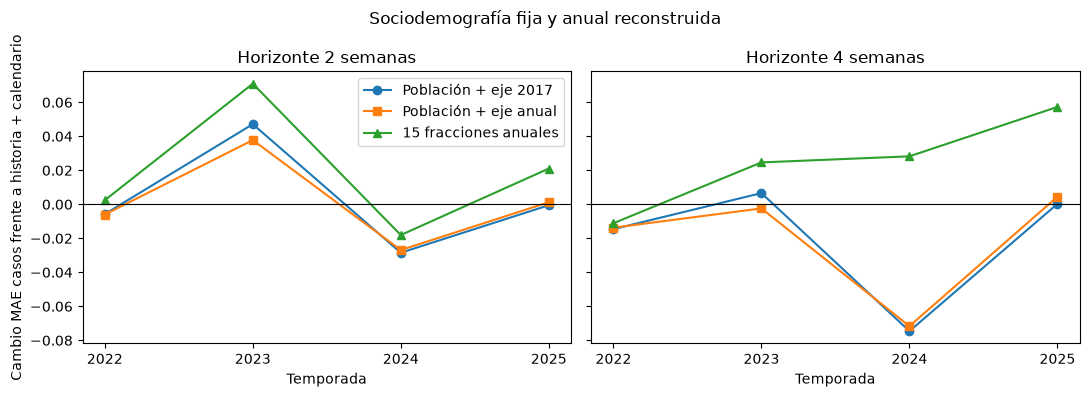

In [3]:
FECHA_DISPONIBLE = '2019-01-01'
resultados, ajustes_pca = contrastar_sociodemografia(panel, FECHA_DISPONIBLE)
tabla = resultados.pivot(index=['horizonte', 'temporada'], columns='modelo', values='mae_casos')
comparacion = pd.DataFrame({
    'base': tabla.historia_calendario,
    'delta_poblacion_2017': tabla.mas_poblacion_2017 - tabla.historia_calendario,
    'delta_tres_fracciones_2017': tabla.mas_tres_fracciones_2017 - tabla.historia_calendario,
    'delta_eje_2017': tabla.mas_eje_urbano_2017 - tabla.historia_calendario,
    'delta_poblacion_y_eje_2017': tabla.mas_poblacion_y_eje - tabla.historia_calendario,
    'delta_poblacion_anual': tabla.mas_poblacion_anual - tabla.historia_calendario,
    'delta_tres_fracciones_anuales': tabla.mas_tres_fracciones_anuales - tabla.historia_calendario,
    'delta_eje_anual': tabla.mas_eje_urbano_anual - tabla.historia_calendario,
    'delta_15_fracciones_anuales': tabla.mas_15_fracciones_anuales - tabla.historia_calendario,
    'delta_poblacion_y_eje_anual': tabla.mas_poblacion_y_eje_anual - tabla.historia_calendario,
    'delta_socio_fijo_sobre_clima': tabla.mas_clima_poblacion_y_eje - tabla.mas_clima,
    'delta_socio_anual_sobre_clima': tabla.mas_clima_poblacion_y_eje_anual - tabla.mas_clima,
})
display(comparacion.round(3))
display(ajustes_pca)
metricas = {
    'descripcion': 'Ablación ridge sobre conteos; mismos train/test por variante en cada fold',
    'fecha_disponible_supuesta_para_origen_prueba': FECHA_DISPONIBLE,
    'etiquetas_2017_2018_en_entrenamiento': True,
    'fuente_socio_fija': 'Excel bronze, columnas observadas de 2017',
    'fuente_socio_anual': 'Silver: población proyectada 2018-2025 y fracciones 2018-2024 interpoladas con 2025',
    'limitacion_temporal': 'Las variantes anuales son reconstrucciones retrospectivas, no backtests en tiempo real',
    'pca': 'Ajuste por fold con fracciones 2017 de distritos de entrenamiento; misma escala y cargas para todos los años',
    'fracciones_directas': ['fraccion_rural', 'fraccion_menores_15', 'fraccion_desague_red'],
    'filas_panel': len(panel), 'distritos': int(panel.ubigeo.nunique()),
    'desvio_maximo_bronze_2017': max(desvios.values()),
    'resultados': resultados.to_dict(orient='records'),
    'ajustes_pca': ajustes_pca.to_dict(orient='records'),
}
(METRICAS / 'fase5_sociodemografia.json').write_text(json.dumps(metricas, ensure_ascii=False, indent=2) + '\n', encoding='utf-8')
fig, ejes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, h in zip(ejes, (2, 4)):
    d = comparacion.xs(h, level='horizonte')
    ax.plot(d.index, d.delta_poblacion_y_eje_2017, marker='o', label='Población + eje 2017')
    ax.plot(d.index, d.delta_poblacion_y_eje_anual, marker='s', label='Población + eje anual')
    ax.plot(d.index, d.delta_15_fracciones_anuales, marker='^', label='15 fracciones anuales')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xticks([2022, 2023, 2024, 2025])
    ax.set(xlabel='Temporada', title=f'Horizonte {h} semanas')
ejes[0].set_ylabel('Cambio MAE casos frente a historia + calendario')
ejes[0].legend()
fig.suptitle('Sociodemografía fija y anual reconstruida')
fig.tight_layout()
fig.savefig(FIGURAS / '01_ablacion_sociodemografia.png', dpi=140)
plt.show()

## Lectura

Un delta negativo favorece el rasgo añadido. Comparar el eje anual con las tres y con las 15 fracciones evita asumir que PCA es la mejor representación. El eje usa una misma definición para todos los años, pero su trayectoria entre 2018 y 2024 depende del valor de 2025. Ni un resultado favorable de ridge ni una correlación transversal justifican por sí solos incluir estas variables en el XGBoost final; sus métricas no simulan las fuentes disponibles en cada origen histórico.